In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
data       = pd.read_csv('/content/drive/MyDrive/nifty50_processed_data.csv')
portfolios = pd.read_csv('/content/drive/MyDrive/nifty50_portfolios.csv')
perf_df    = pd.read_csv('/content/drive/MyDrive/nifty50_portfolio_performance.csv')

data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(['Symbol','Date'], inplace=True)
data.reset_index(drop=True, inplace=True)

# Build price matrix and returns matrix
price_matrix   = data.pivot_table(index='Date', columns='Symbol', values='Close')
price_matrix   = price_matrix.fillna(method='ffill').fillna(method='bfill')
returns_matrix = price_matrix.pct_change().dropna()

print("Data loaded ✅")
print(f"Price matrix  : {price_matrix.shape}")
print(f"Returns matrix: {returns_matrix.shape}")

Mounted at /content/drive
Data loaded ✅
Price matrix  : (5306, 49)
Returns matrix: (5305, 49)


In [2]:
def compute_stock_risk(returns, risk_free_rate=0.06):
    """Compute all risk metrics for a single stock"""
    daily_rf = risk_free_rate / 252

    # Annualized return and volatility
    ann_return = returns.mean() * 252
    ann_vol    = returns.std() * np.sqrt(252)

    # Sharpe Ratio
    sharpe = (ann_return - risk_free_rate) / ann_vol

    # Sortino Ratio (downside deviation only)
    downside = returns[returns < daily_rf]
    downside_std = downside.std() * np.sqrt(252)
    sortino = (ann_return - risk_free_rate) / downside_std if downside_std > 0 else 0

    # Maximum Drawdown
    cum_returns  = (1 + returns).cumprod()
    rolling_max  = cum_returns.cummax()
    drawdown     = (cum_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Value at Risk (95% confidence)
    var_95 = np.percentile(returns, 5)

    # Conditional VaR (Expected Shortfall)
    cvar_95 = returns[returns <= var_95].mean()

    return {
        'Annual_Return'  : round(ann_return * 100, 2),
        'Volatility'     : round(ann_vol * 100, 2),
        'Sharpe_Ratio'   : round(sharpe, 4),
        'Sortino_Ratio'  : round(sortino, 4),
        'Max_Drawdown'   : round(max_drawdown * 100, 2),
        'VaR_95'         : round(var_95 * 100, 2),
        'CVaR_95'        : round(cvar_95 * 100, 2)
    }

# Compute for all stocks
risk_records = []
for symbol in returns_matrix.columns:
    metrics = compute_stock_risk(returns_matrix[symbol].dropna())
    metrics['Symbol'] = symbol
    risk_records.append(metrics)

risk_df = pd.DataFrame(risk_records).set_index('Symbol')
risk_df = risk_df[['Annual_Return','Volatility','Sharpe_Ratio',
                    'Sortino_Ratio','Max_Drawdown','VaR_95','CVaR_95']]

print("Risk metrics computed ✅")
print(risk_df.sort_values('Sharpe_Ratio', ascending=False).to_string())

Risk metrics computed ✅
            Annual_Return  Volatility  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  VaR_95  CVaR_95
Symbol                                                                                           
SHREECEM            35.92       37.77        0.7920         1.2094        -79.97   -3.46    -5.01
BAJFINANCE          38.47       48.33        0.6717         0.8135        -93.28   -3.83    -6.26
EICHERMOT           34.67       48.02        0.5971         0.7470        -93.82   -3.73    -5.95
MARUTI              22.40       31.50        0.5205         0.7406        -61.34   -2.89    -4.47
AXISBANK            29.67       48.48        0.4883         0.6174        -85.02   -4.16    -6.35
TITAN               30.40       50.00        0.4881         0.5974        -96.69   -4.05    -6.36
INDUSINDBK          28.92       49.15        0.4664         0.6224        -85.11   -4.02    -6.81
ULTRACEMCO          19.42       29.39        0.4568         0.6586        -77.78   -2.77    -4

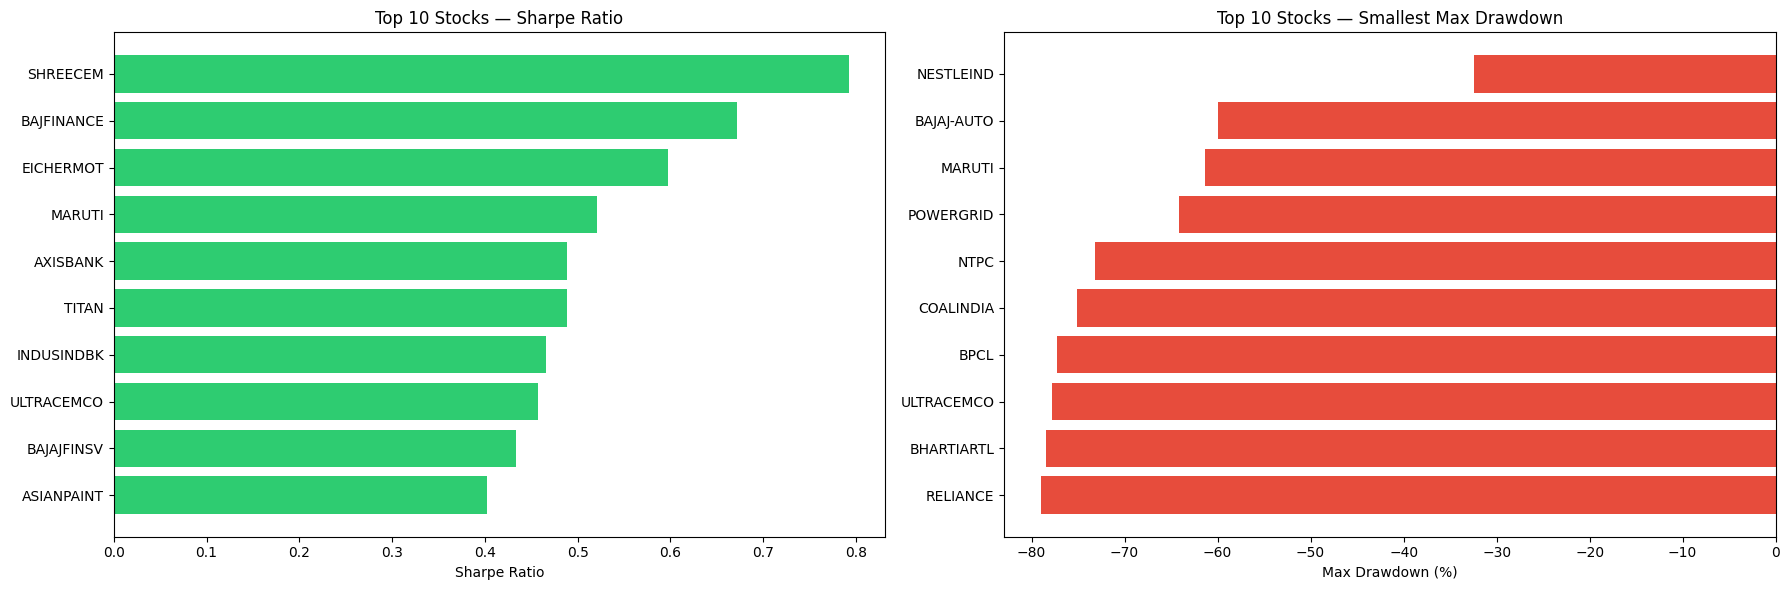

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 by Sharpe Ratio
top_sharpe = risk_df.sort_values('Sharpe_Ratio', ascending=False).head(10)
axes[0].barh(top_sharpe.index, top_sharpe['Sharpe_Ratio'], color='#2ecc71')
axes[0].set_title('Top 10 Stocks — Sharpe Ratio', fontsize=12)
axes[0].set_xlabel('Sharpe Ratio')
axes[0].invert_yaxis()

# Top 10 by Max Drawdown (least negative = best)
best_drawdown = risk_df.sort_values('Max_Drawdown', ascending=False).head(10)
axes[1].barh(best_drawdown.index, best_drawdown['Max_Drawdown'], color='#e74c3c')
axes[1].set_title('Top 10 Stocks — Smallest Max Drawdown', fontsize=12)
axes[1].set_xlabel('Max Drawdown (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

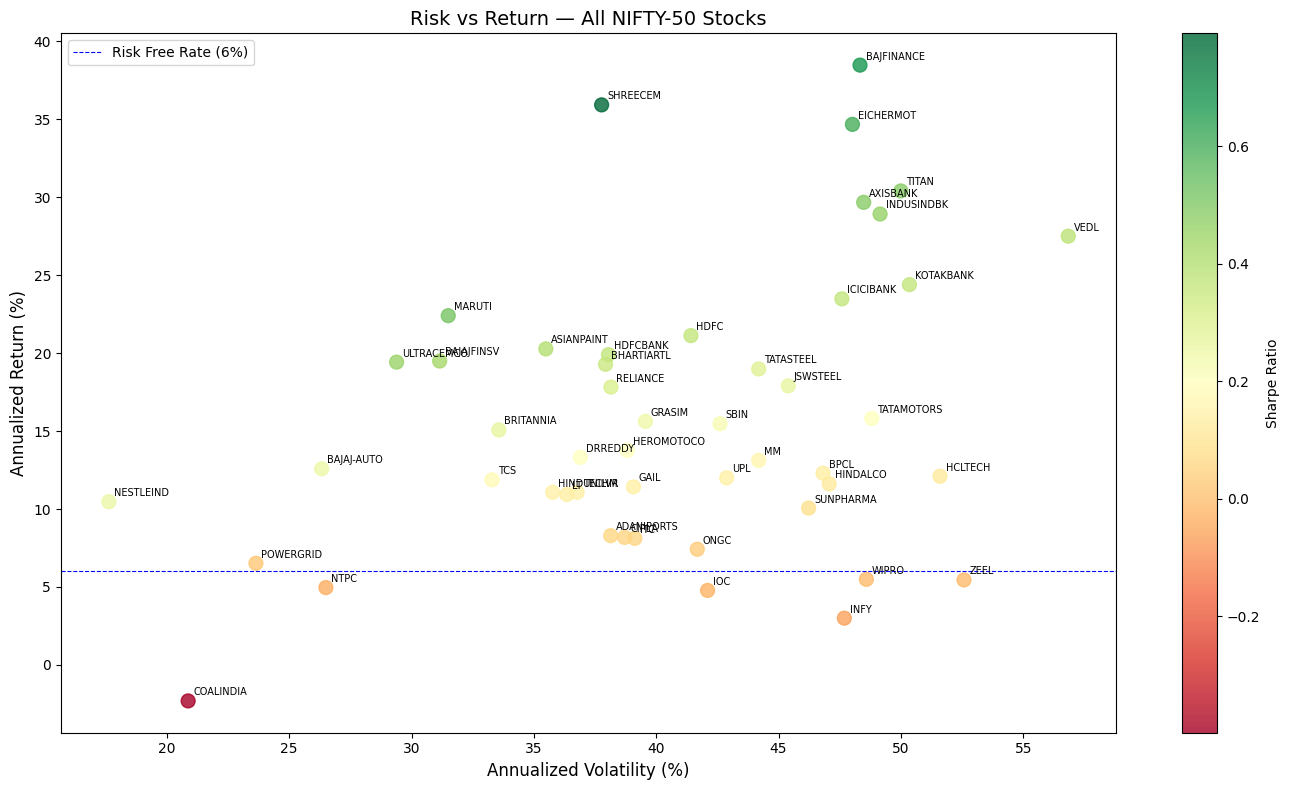

In [4]:
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    risk_df['Volatility'],
    risk_df['Annual_Return'],
    c=risk_df['Sharpe_Ratio'],
    cmap='RdYlGn',
    s=100,
    alpha=0.8
)

# Label each stock
for symbol, row in risk_df.iterrows():
    plt.annotate(symbol,
                 (row['Volatility'], row['Annual_Return']),
                 fontsize=7,
                 xytext=(4, 4),
                 textcoords='offset points')

plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualized Volatility (%)', fontsize=12)
plt.ylabel('Annualized Return (%)', fontsize=12)
plt.title('Risk vs Return — All NIFTY-50 Stocks', fontsize=14)
plt.axhline(y=6, color='blue', linestyle='--', linewidth=0.8, label='Risk Free Rate (6%)')
plt.legend()
plt.tight_layout()
plt.show()

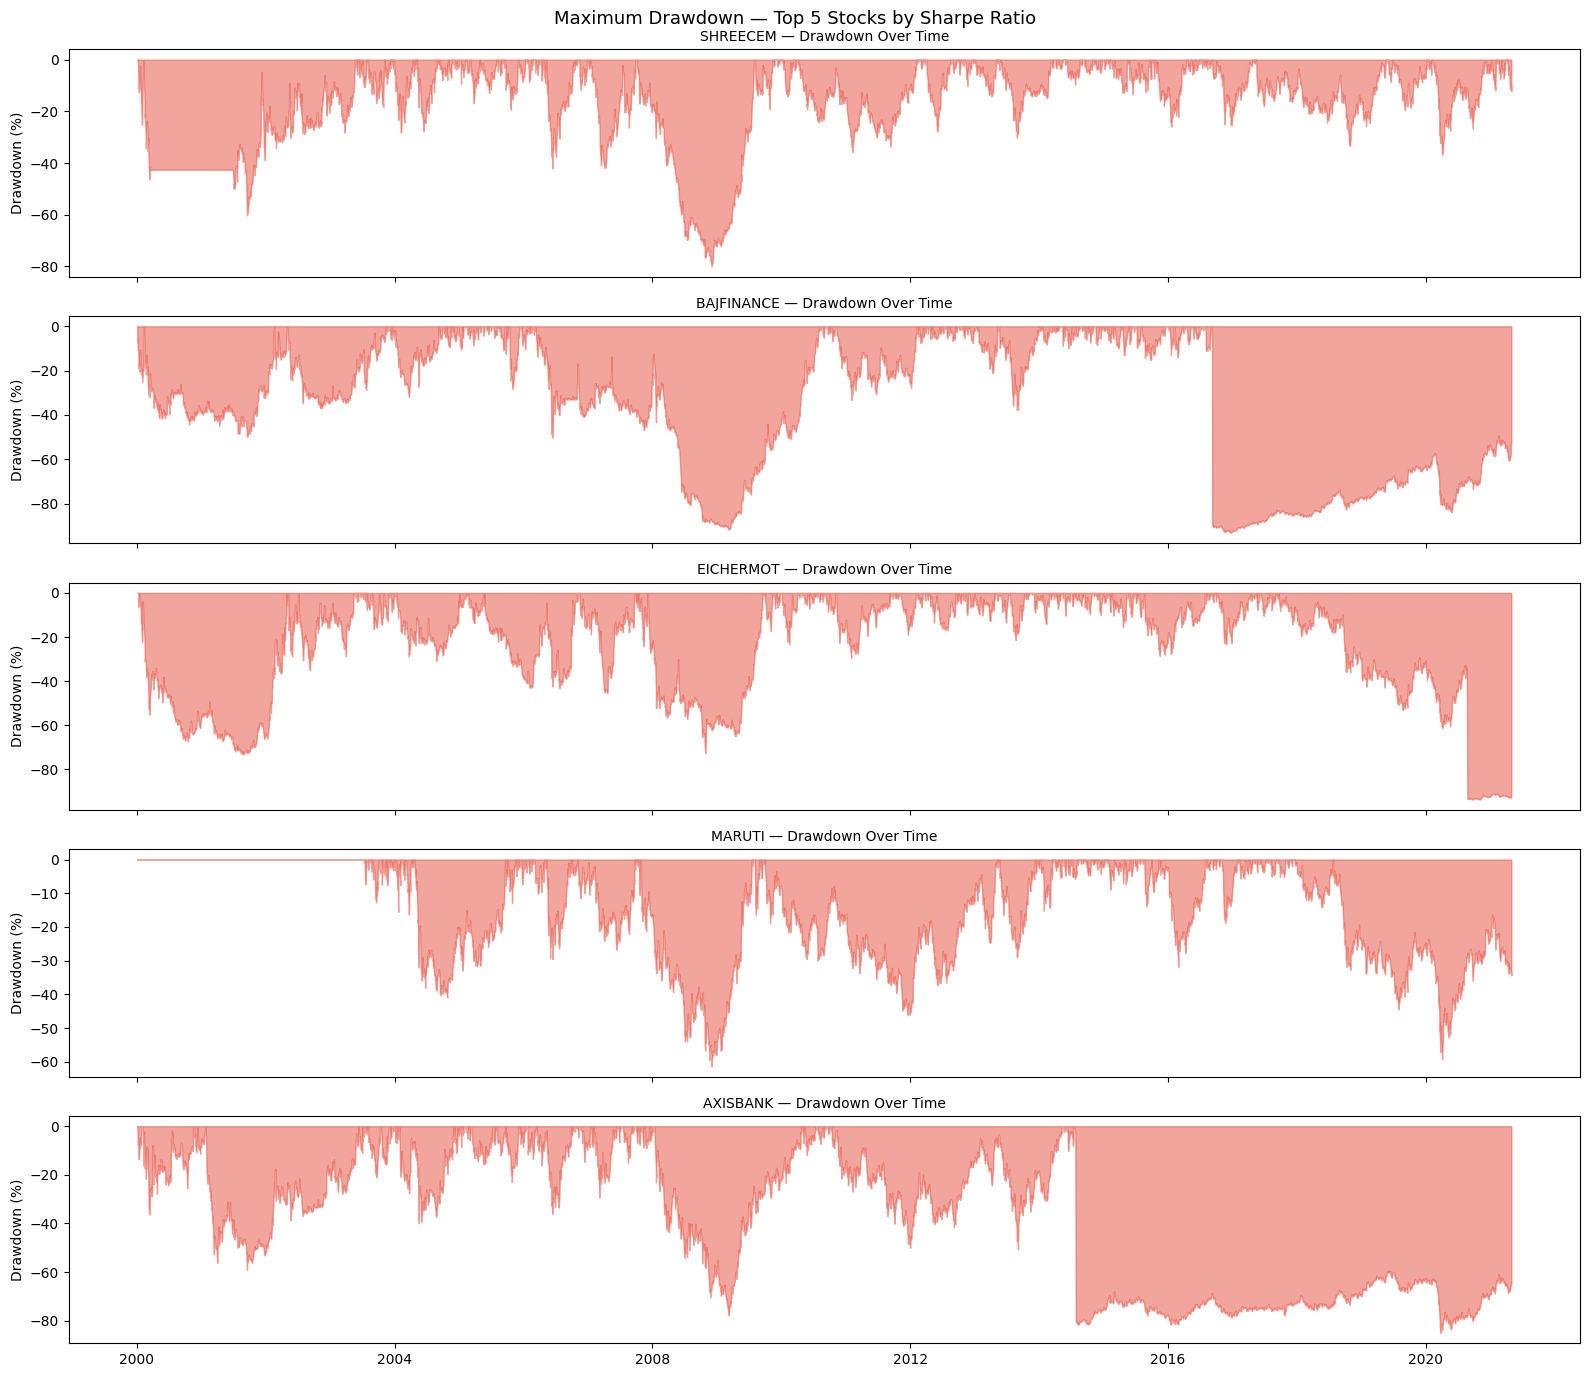

In [5]:
# Plot drawdown over time for top 5 stocks by Sharpe
top5 = risk_df.sort_values('Sharpe_Ratio', ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(len(top5), 1, figsize=(16, 14), sharex=True)

for ax, symbol in zip(axes, top5):
    ret          = returns_matrix[symbol].dropna()
    cum_ret      = (1 + ret).cumprod()
    rolling_max  = cum_ret.cummax()
    drawdown     = (cum_ret - rolling_max) / rolling_max * 100

    ax.fill_between(drawdown.index, drawdown.values, 0,
                    color='#e74c3c', alpha=0.5)
    ax.set_title(f'{symbol} — Drawdown Over Time', fontsize=10)
    ax.set_ylabel('Drawdown (%)')

plt.suptitle('Maximum Drawdown — Top 5 Stocks by Sharpe Ratio', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
def portfolio_risk(weights_df, returns_matrix, risk_free_rate=0.06):
    """Compute risk metrics for a portfolio given weights"""
    # Align weights with available stocks
    symbols = [s for s in weights_df['Symbol'] if s in returns_matrix.columns]
    weights = weights_df[weights_df['Symbol'].isin(symbols)].set_index('Symbol')['Weight']
    weights = weights / weights.sum()  # normalize

    # Portfolio daily returns
    port_returns = returns_matrix[symbols].dot(weights)

    metrics = compute_stock_risk(port_returns, risk_free_rate)
    return metrics, port_returns

# Compute for each portfolio
profiles = ['Conservative', 'Balanced', 'Aggressive']
port_metrics = {}
port_returns_dict = {}

for profile in profiles:
    w = portfolios[portfolios['Profile'] == profile][['Symbol','Weight_Pct']].copy()
    w['Weight'] = w['Weight_Pct'] / 100
    metrics, port_ret = portfolio_risk(w, returns_matrix)
    port_metrics[profile] = metrics
    port_returns_dict[profile] = port_ret

port_risk_df = pd.DataFrame(port_metrics).T
print("Portfolio Risk Metrics:")
print(port_risk_df.to_string())

Portfolio Risk Metrics:
              Annual_Return  Volatility  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  VaR_95  CVaR_95
Conservative          13.91       18.56        0.4261         0.4949        -34.43   -1.64    -2.81
Balanced              33.78       28.40        0.9781         1.3971        -73.63   -2.61    -3.95
Aggressive            24.69       26.80        0.6974         0.9681        -57.00   -2.29    -3.80


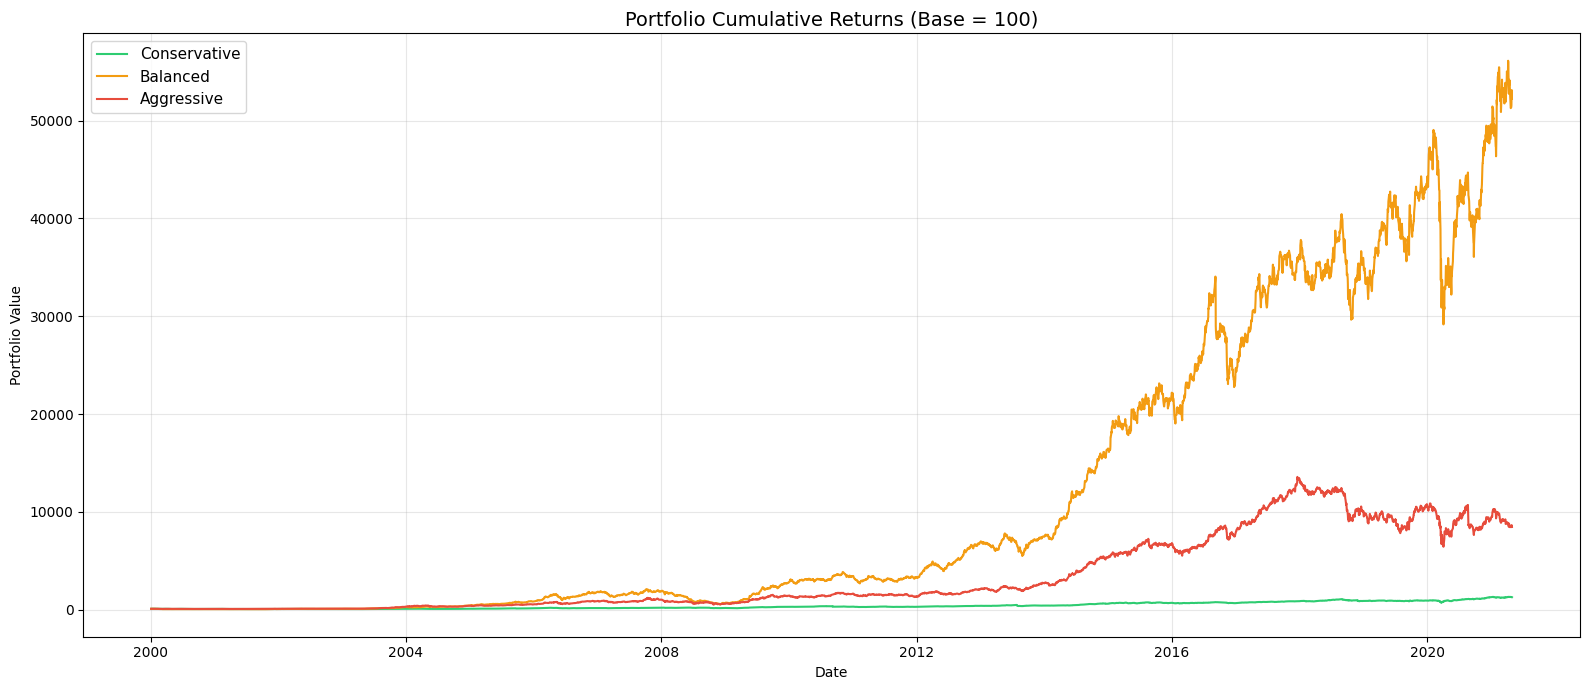

In [7]:
plt.figure(figsize=(16, 7))

colors = {'Conservative': '#2ecc71', 'Balanced': '#f39c12', 'Aggressive': '#e74c3c'}

for profile, port_ret in port_returns_dict.items():
    cum_ret = (1 + port_ret).cumprod() * 100
    plt.plot(cum_ret.index, cum_ret.values,
             label=profile, color=colors[profile], linewidth=1.5)

plt.title('Portfolio Cumulative Returns (Base = 100)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

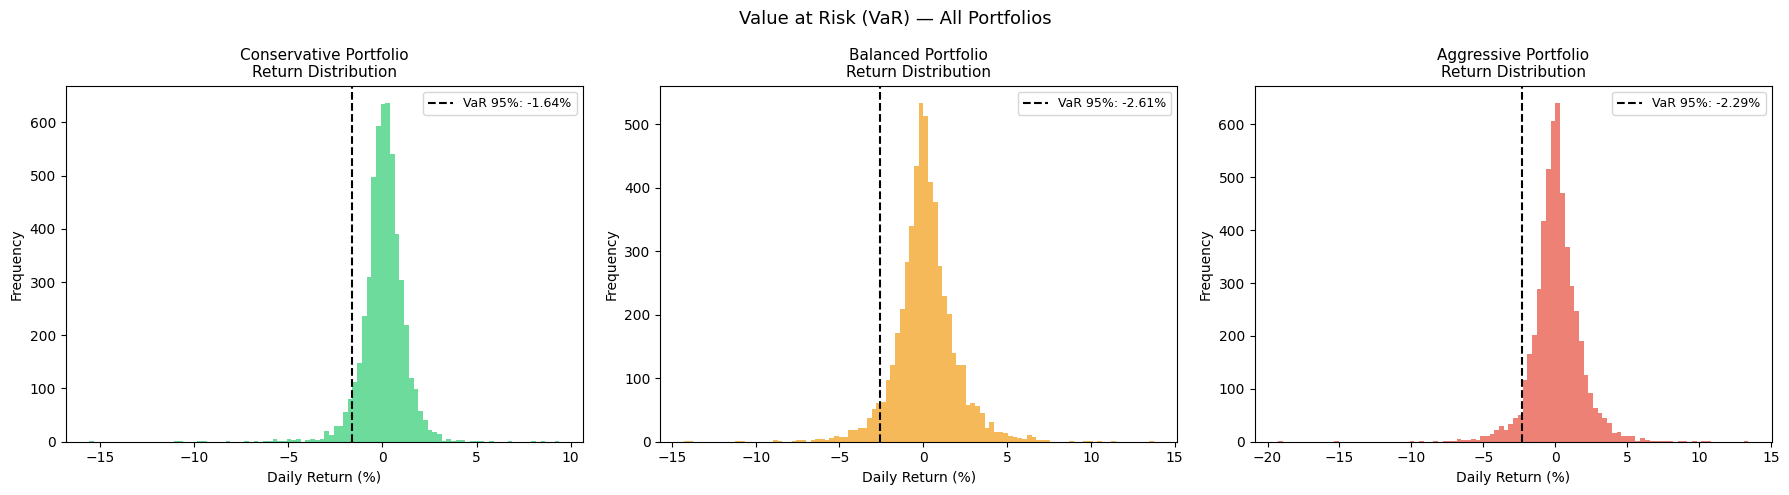

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, profile in zip(axes, profiles):
    port_ret = port_returns_dict[profile]
    var_95   = np.percentile(port_ret, 5)

    ax.hist(port_ret * 100, bins=100, color=colors[profile],
            alpha=0.7, edgecolor='none')
    ax.axvline(var_95 * 100, color='black', linestyle='--',
               linewidth=1.5, label=f'VaR 95%: {var_95*100:.2f}%')
    ax.set_title(f'{profile} Portfolio\nReturn Distribution', fontsize=11)
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Value at Risk (VaR) — All Portfolios', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Combine stock risk + portfolio risk into one summary
print("=" * 60)
print("PORTFOLIO RISK SUMMARY")
print("=" * 60)
print(port_risk_df[['Annual_Return','Volatility','Sharpe_Ratio',
                     'Sortino_Ratio','Max_Drawdown','VaR_95']].to_string())

print("\n" + "=" * 60)
print("TOP 10 STOCKS BY SHARPE RATIO")
print("=" * 60)
print(risk_df.sort_values('Sharpe_Ratio', ascending=False)
      .head(10)[['Annual_Return','Volatility','Sharpe_Ratio',
                 'Sortino_Ratio','Max_Drawdown','VaR_95']].to_string())

print("\n" + "=" * 60)
print("TOP 10 RISKIEST STOCKS")
print("=" * 60)
print(risk_df.sort_values('Volatility', ascending=False)
      .head(10)[['Annual_Return','Volatility','Sharpe_Ratio',
                 'Max_Drawdown','VaR_95']].to_string())

PORTFOLIO RISK SUMMARY
              Annual_Return  Volatility  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  VaR_95
Conservative          13.91       18.56        0.4261         0.4949        -34.43   -1.64
Balanced              33.78       28.40        0.9781         1.3971        -73.63   -2.61
Aggressive            24.69       26.80        0.6974         0.9681        -57.00   -2.29

TOP 10 STOCKS BY SHARPE RATIO
            Annual_Return  Volatility  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  VaR_95
Symbol                                                                                  
SHREECEM            35.92       37.77        0.7920         1.2094        -79.97   -3.46
BAJFINANCE          38.47       48.33        0.6717         0.8135        -93.28   -3.83
EICHERMOT           34.67       48.02        0.5971         0.7470        -93.82   -3.73
MARUTI              22.40       31.50        0.5205         0.7406        -61.34   -2.89
AXISBANK            29.67       48.48        0.4

In [10]:
# Save risk metrics
risk_df.to_csv('/content/drive/MyDrive/nifty50_stock_risk.csv')
port_risk_df.to_csv('/content/drive/MyDrive/nifty50_portfolio_risk.csv')

print("Risk metrics saved to Drive ✅")
print("\nFiles saved:")
print("  nifty50_stock_risk.csv")
print("  nifty50_portfolio_risk.csv")
print("\nReady for Phase 6 — Streamlit Dashboard 🚀")

Risk metrics saved to Drive ✅

Files saved:
  nifty50_stock_risk.csv
  nifty50_portfolio_risk.csv

Ready for Phase 6 — Streamlit Dashboard 🚀
